In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numba
import tqdm
import scipy
from matplotlib import lines as mlines
from matplotlib.patches import Rectangle
import seaborn
import os
import sys
import joblib
from itertools import product
from pathlib import Path

In [2]:
path_to_code_repo = "/home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER/"
import matplotlib.font_manager as fm
# ============================================================
# Fonts / style
# ============================================================
font_paths = [
    f"{path_to_code_repo}/fonts/Arial.ttf",
     f"{path_to_code_repo}/fonts/Arial Bold.ttf",
     f"{path_to_code_repo}/fonts/Arial Italic.ttf",
     f"{path_to_code_repo}/fonts/Arial Bold Italic.ttf",
]

for fp in font_paths:
    try:
        fm.fontManager.addfont(fp)
        print("✔ Loaded font:", fp)
    except Exception as e:
        print("⚠️  Could not load:", fp, "|", e)

# ==== LaTeX + SVG text mode (Illustrator-safe) ====
# ==== LaTeX + SVG text mode (Illustrator-safe) ====
import matplotlib.pyplot as plt
plt.rcParams['pdf.fonttype'] = 42  # For PDF export
plt.rcParams['ps.fonttype'] = 42   # For PostScript (EPS) export
plt.rcParams['font.sans-serif'] = ["Arial"]
plt.rcParams['font.family'] = "sans-serif"
plt.rcParams['svg.fonttype'] = "none"
plt.rcParams['mathtext.fontset'] = "cm"
plt.rcParams['axes.labelsize'] = 18*1.5      # x/y labels
plt.rcParams['axes.titlesize'] = 20*1.5 
plt.rcParams['xtick.labelsize'] = 12*1.5     # x-axis tick labels
plt.rcParams['ytick.labelsize'] = 12*1.5    # y-axis tick labels
plt.rcParams['legend.fontsize'] = 12*1.5     # legend text

✔ Loaded font: /home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER//fonts/Arial.ttf
✔ Loaded font: /home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER//fonts/Arial Bold.ttf
✔ Loaded font: /home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER//fonts/Arial Italic.ttf
✔ Loaded font: /home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER//fonts/Arial Bold Italic.ttf


In [3]:
path_to_plot_data = "/home/gzu5140/Keerthana_b1042/grnInference/plot_data/figure_3/"
path_to_plots = "/home/gzu5140/Keerthana_b1042/grnInference/plots/figure_3/"
os.makedirs(path_to_plots, exist_ok=True)

In [4]:
def create_box_plot_and_save(df_results, save_dir):
    """
    Plot 1: Correlations colored by threshold (blue > threshold, red < threshold, grey in between)
    Plot 2: Threshold boxplots in grey
    """
    
    # ==========================================
    # PLOT 1: CORRELATIONS WITH THRESHOLD-BASED COLORS
    # ==========================================
    
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # REMOVE ALL BACKGROUNDS
    fig.patch.set_facecolor('none')  # Figure background transparent
    ax.set_facecolor('none')         # Axes background transparent
    
    conditions = df_results['Condition'].unique()
    
    # Prepare data for each condition
    all_values_12 = []  # gene_1 -> gene_2
    all_values_21 = []  # gene_2 -> gene_1
    all_thresholds = []
    all_thresholds_12 = []
    all_thresholds_21 = []
    
    for condition in conditions:
        condition_data = df_results[df_results['Condition'] == condition]
        vals_12 = condition_data['gene_1_to_gene_2'].values.tolist()
        vals_21 = condition_data['gene_2_to_gene_1'].values.tolist()
        threshold_combined = condition_data['threshold_combined'].values.tolist()
        threshold_12 = condition_data['threshold_12'].values.tolist()
        threshold_21 = condition_data['threshold_21'].values.tolist()
        
        all_values_12.append(vals_12)
        all_values_21.append(vals_21)
        all_thresholds_12.append(threshold_12)
        all_thresholds_21.append(threshold_21)
        all_thresholds.append(threshold_combined)
    
    # Flatten thresholds for range calculation
    flat_thresholds = [item for sublist in all_thresholds for item in sublist]
    
    # Add threshold range background
    x_range = np.arange(0.5, len(conditions) + 0.5, 0.01)
    
    # Add threshold lines
    # Add threshold lines
    ax.axhline(np.mean(flat_thresholds),
            linestyle="--",
            color="black",
            linewidth=1,
            alpha=0.7,
            dashes=(12, 4))    # 8pt dash, 4pt gap

    ax.axhline(-np.mean(flat_thresholds),
            linestyle="--",
            color="black",
            linewidth=1,
            alpha=0.7,
            dashes=(12,4))
    
    # Function to determine color based on threshold
    def get_threshold_color(values, thresholds):
        """Determine color based on whether median is above, below, or between thresholds"""
        median_val = np.median(values)
        mean_threshold = np.mean(thresholds)
        
        if median_val > mean_threshold:
            return 'blue'
        elif median_val < -mean_threshold:
            return 'red' 
        else:
            return 'grey'
    
    # Create boxplots for gene_1 -> gene_2
    positions_12 = [i - 0.2 for i in range(1, len(conditions) + 1)]
    box_12 = ax.boxplot(all_values_12, positions=positions_12, patch_artist=True, 
                        showfliers=False, widths=0.3)
    
    # Create boxplots for gene_2 -> gene_1  
    positions_21 = [i + 0.2 for i in range(1, len(conditions) + 1)]
    box_21 = ax.boxplot(all_values_21, positions=positions_21, patch_artist=True, 
                        showfliers=False, widths=0.3)
    solid = mlines.Line2D([], [], color="black", linestyle="-",
                      label=r"$\hat{\rho}^{\dagger}_{x(t_{1}) \to y(t_{2})}$")

    dashed = mlines.Line2D([], [], color="black", linestyle="--",
                        label=r"$\hat{\rho}^{\dagger}_{y(t_{1}) \to x(t_{2})}$")

    ax.legend(handles=[solid, dashed])
    
    # Color gene_1 -> gene_2 boxplots based on threshold (outline only)
    for i, (patch, values, thresholds) in enumerate(zip(box_12['boxes'], all_values_12, all_thresholds_12)):
        color = get_threshold_color(values, thresholds)
        patch.set_facecolor('none')  # No fill color
        patch.set_edgecolor(color)
        patch.set_linewidth(2)
        patch.set_clip_on(False)
    
    for i, (whisker, values, thresholds) in enumerate(zip(box_12['whiskers'], all_values_12 * 2, all_thresholds_12 * 2)):
        if i < len(all_values_12) * 2:  # Handle whisker indexing
            condition_idx = i // 2
            if condition_idx < len(all_values_12):
                color = get_threshold_color(all_values_12[condition_idx], all_thresholds_12[condition_idx])
                whisker.set_color(color)
                whisker.set_linewidth(2)
        whisker.set_clip_on(False)
    
    for i, (cap, values, thresholds) in enumerate(zip(box_12['caps'], all_values_12 * 2, all_thresholds_12 * 2)):
        if i < len(all_values_12) * 2:  # Handle cap indexing
            condition_idx = i // 2
            if condition_idx < len(all_values_12):
                color = get_threshold_color(all_values_12[condition_idx], all_thresholds_12[condition_idx])
                cap.set_color(color)
                cap.set_linewidth(2)
        cap.set_clip_on(False)
    
    for i, (median, values, thresholds) in enumerate(zip(box_12['medians'], all_values_12, all_thresholds_12)):
        color = get_threshold_color(values, thresholds)
        median.set_color(color)
        median.set_linewidth(2)
        median.set_clip_on(False)
    
    # Color gene_2 -> gene_1 boxplots based on threshold (outline only)
    for i, (patch, values, thresholds) in enumerate(zip(box_21['boxes'], all_values_21, all_thresholds_21)):
        color = get_threshold_color(values, thresholds)
        patch.set_facecolor('none')  # No fill color
        patch.set_edgecolor(color)
        patch.set_linestyle("--")
        patch.set_linewidth(2)
        patch.set_clip_on(False)

    for i, (whisker, values, thresholds) in enumerate(zip(box_21['whiskers'], all_values_21 * 2, all_thresholds_21 * 2)):
        if i < len(all_values_21) * 2:  # Handle whisker indexing
            condition_idx = i // 2
            if condition_idx < len(all_values_21):
                color = get_threshold_color(all_values_21[condition_idx], all_thresholds_21[condition_idx])
                whisker.set_color(color)
                whisker.set_linewidth(2)
        whisker.set_clip_on(False)
    
    for i, (cap, values, thresholds) in enumerate(zip(box_21['caps'], all_values_21 * 2, all_thresholds_21 * 2)):
        if i < len(all_values_21) * 2:  # Handle cap indexing
            condition_idx = i // 2
            if condition_idx < len(all_values_21):
                color = get_threshold_color(all_values_21[condition_idx], all_thresholds_21[condition_idx])
                cap.set_color(color)
                cap.set_linewidth(2)
        cap.set_clip_on(False)
    
    for i, (median, values, thresholds) in enumerate(zip(box_21['medians'], all_values_21, all_thresholds_21)):
        color = get_threshold_color(values, thresholds)
        median.set_color(color)
        median.set_linewidth(2)
        median.set_clip_on(False)
    
    # Set custom tick labels
    folder_names = ["1", "2", "3", "4", "5", "6"]
    ax.set_xticks(range(1, len(conditions) + 1))
    ax.set_xticklabels(folder_names[:len(conditions)], ha="center")
    ax.tick_params(axis='both', which='both', 
                bottom=True, top=False, left=True, right=False,
                labelbottom=True, labelleft=True,
                length=4, width=1)
    plt.ylabel(r"twin cross-correlation")
    plt.savefig(os.path.join(save_dir, 'correlations_with_thresholds.svg'), 
                format='svg', bbox_inches='tight', 
                facecolor='none', edgecolor='none', transparent=True)
    plt.savefig(os.path.join(save_dir, 'correlations_with_thresholds.pdf'), 
                format='pdf', bbox_inches='tight', 
                facecolor='none', edgecolor='none', transparent=True)
    plt.show()
    
    # ==========================================
    # PLOT 2: THRESHOLD BOX PLOTS (GREY)
    # ==========================================
    
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # REMOVE ALL BACKGROUNDS
    fig.patch.set_facecolor('none')
    ax.set_facecolor('none')
    
    # Create side-by-side boxplots for thresholds
    positions_12 = [i - 0.2 for i in range(1, len(conditions) + 1)]
    box_thresh_12 = ax.boxplot(all_thresholds_12, positions=positions_12, 
                               patch_artist=True, showfliers=True, widths=0.3)
    
    positions_21 = [i + 0.2 for i in range(1, len(conditions) + 1)]
    box_thresh_21 = ax.boxplot(all_thresholds_21, positions=positions_21, 
                               patch_artist=True, showfliers=True, widths=0.3)
    
    # Style all threshold boxplots in grey (outline only)
    for patch in box_thresh_12['boxes']:
        patch.set_facecolor('none')  # No fill color
        patch.set_edgecolor('grey')
        patch.set_linewidth(2)
        patch.set_clip_on(False)
    
    for whisker in box_thresh_12['whiskers'] + box_thresh_12['caps'] + box_thresh_12['medians']:
        whisker.set_color('grey')
        whisker.set_linewidth(2)
        whisker.set_clip_on(False)
    
    for patch in box_thresh_21['boxes']:
        patch.set_facecolor('none')  # No fill color
        patch.set_edgecolor('grey')
        patch.set_linewidth(2)
        patch.set_linestyle("--")
        patch.set_clip_on(False)

    for flier in box_thresh_21['fliers']:
        flier.set_markerfacecolor('grey')
        flier.set_markeredgecolor('grey')
        flier.set_markersize(2)

    for flier in box_thresh_12['fliers']:
        flier.set_markerfacecolor('grey')
        flier.set_markeredgecolor('grey')
        flier.set_markersize(2)

    for whisker in box_thresh_21['whiskers'] + box_thresh_21['caps'] + box_thresh_21['medians']:
        whisker.set_color('grey')
        whisker.set_linewidth(2)
        whisker.set_clip_on(False)
    
    # Add mean threshold line
    ax.axhline(np.mean(flat_thresholds), linestyle="--", color="black", linewidth=1, alpha=0.7, dashes=(12,4))
    solid = mlines.Line2D([], [], color="black", linestyle="-",
                      label=r"$\rho^{\dagger}_{x(t_{1}) \to y(t_{2})}$")

    dashed = mlines.Line2D([], [], color="black", linestyle="--",
                        label=r"$\rho^{\dagger}_{y(t_{1}) \to x(t_{2})}$")

    ax.legend(handles=[solid, dashed])
    # Set custom tick labels  
    folder_names = ["A_B", "A_to_B", "A_to_B_B_to_A", "A_rep_B", "A_rep_B_B_rep_A", "A_rep_B_B_to_A"]
    ax.set_xticks(range(1, len(conditions) + 1))
    ax.set_xticklabels(folder_names[:len(conditions)])
    ax.tick_params(axis='both', which='both', 
                bottom=True, top=False, left=True, right=False,
                labelbottom=True, labelleft=True,
                length=4, width=1)
    plt.ylabel(r"random-pair cross-correlation")
    # Uncomment to save the second plot
    plt.savefig(os.path.join(save_dir, 'threshold_boxplots.svg'), 
                format='svg', bbox_inches='tight',
                facecolor='none', edgecolor='none', transparent=True)
    plt.savefig(os.path.join(save_dir, 'threshold_boxplots.pdf'), 
                format='pdf', bbox_inches='tight',
                facecolor='none', edgecolor='none', transparent=True)
    plt.show()
    
    print(f"Saved plots to {save_dir}:")
    print("1. correlations_with_thresholds.pdf")
    print("2. threshold_boxplots.pdf")
    
    return None

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path
import glob
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap


def make_reds_blues_colormap(vmin=-0.05, vmax=0.18):
    """Custom red–white–blue colormap with pure white at 0, asymmetric."""
    # Calculate where 0 falls in the range [vmin, vmax]
    zero_position = max(0, (0 - vmin) / (vmax - vmin))
    
    # Number of colors for each segment (proportional to range)
    n_total = 256
    n_reds = int(zero_position * n_total)  # colors from vmin to 0
    n_blues = n_total - n_reds  # colors from 0 to vmax
    
    # Calculate intensity based on actual distance from zero
    # For reds: map from vmin to 0, so max intensity at vmin
    red_intensity = abs(vmin) / max(abs(vmin), abs(vmax))  # 0.05/0.18 ≈ 0.28
    # For blues: map from 0 to vmax, so max intensity at vmax  
    blue_intensity = abs(vmax) / max(abs(vmin), abs(vmax))  # 0.18/0.18 = 1.0
    
    # Create color arrays with scaled intensities
    reds = plt.cm.Reds(np.linspace(0.8 * red_intensity, 0, n_reds))  # scaled dark to light red
    whites = np.ones((1, 4))  # pure white at 0
    blues = plt.cm.Blues(np.linspace(0, 0.8 * blue_intensity, n_blues))  # light to scaled dark blue
    
    colors = np.vstack((reds, whites, blues))
    return LinearSegmentedColormap.from_list('RedsBlues', colors)


def find_global_correlation_range(data_folder):
    csv_files = glob.glob(str(Path(data_folder) / "*.csv"))
    all_values = []
    for file_path in csv_files:
        if "filtered" in file_path in file_path:
            df = pd.read_csv(file_path, index_col=0)
            arr = df.to_numpy().copy()
            np.fill_diagonal(arr, np.nan)
            masked_matrix = pd.DataFrame(arr, index=df.index, columns=df.columns)
            all_values.extend(masked_matrix.values.flatten())
    all_values = [v for v in all_values if not np.isnan(v)]
    if not all_values:
        raise ValueError("No valid numeric values found in any CSV files")
    return np.min(all_values), np.max(all_values)


def convert_gene_labels(labels, axis='x'):
    converted = []
    for label in labels:
        if label.startswith('gene_'):
            num = int(label.replace('gene_', ''))
            letter = chr(ord('A') + num - 1)
        elif label.startswith('g'):
            num = int(label[1:])
            letter = chr(ord('A') + num - 1)
        else:
            letter = label
        converted.append(
            rf"$\text{{{letter}}}$" if axis == 'x'
            else rf"$\text{{{letter}}}$"
        )


    return converted

def plot_all_correlations_common_scale(
    data_folder, 
    path_to_plots=None, 
    figsize_per_plot=(8, 8), 
    use_symmetric_scale=False,
    matrix_type="correlation"
):
    """
    Plot all correlation matrices.
    • white = 0
    • gray = diagonal
    • transparent background (Illustrator-friendly)
    """

    # --- global scale ---
    global_min, global_max = find_global_correlation_range(data_folder)
    print(f"Global range: {global_min:.3f} → {global_max:.3f}")

    # --- normalization ---
    if use_symmetric_scale:
        max_abs = max(abs(global_min), abs(global_max))
        vmin, vmax = -max_abs, max_abs
        norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
        center = 0
    else:
        vmin, vmax = global_min, global_max
        print(vmin, vmax)
        norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
        center = 0

    cmap = make_reds_blues_colormap()

    csv_files = sorted(glob.glob(str(Path(data_folder) / "*.csv")))

    for file_path in csv_files:
        filename = Path(file_path).stem
        if ("filtered" not in filename):
            continue
        print(f"Processing: {filename}")
        if "five" in filename:
            figsize_per_plot = (9,8)
        else:
            figsize_per_plot = (5,4)

        df = pd.read_csv(file_path, index_col=0)
        print(file_path)
        data_matrix = df.to_numpy(float)
        # 1. diagonal = gray
        

        # 2. mask the diagonal
        data_matrix = df.to_numpy(float)
        np.fill_diagonal(data_matrix, np.nan)

        # fig = plt.figure(figsize=figsize_per_plot)
        # gs = fig.add_gridspec(2, 1, height_ratios=[0.05, 0.95], hspace=0.1)
        # cbar_ax = fig.add_subplot(gs[0])
        # heatmap_ax = fig.add_subplot(gs[1])
        # cmap.set_bad(color="#D9D9D9")
        # # # --- draw heatmap ---


        # # --- transparent background ---
        # plt.tight_layout()
        # fig.patch.set_alpha(0)
        fig = plt.figure(figsize=figsize_per_plot)

        # vertical cbar on the left
        gs = fig.add_gridspec(
            1, 2,
            width_ratios=[0.08, 0.92],
            wspace=0.05
        )

        cbar_ax = fig.add_subplot(gs[0])
        heatmap_ax = fig.add_subplot(gs[1])

        sns.heatmap(
            data_matrix,
            ax=heatmap_ax,
            cmap=cmap,
            norm=norm,
            vmin=vmin, vmax=vmax,
            square=True,
            cbar=True,
            cbar_ax=cbar_ax,
            cbar_kws={'orientation': 'vertical', 'label': f'twin cross-correlation'},
            linewidth=1,
            linecolor="black"
        )

        # Style the left-side colorbar
        cbar = heatmap_ax.collections[0].colorbar
        cbar_ax.yaxis.set_ticks_position('left')
        cbar_ax.yaxis.set_label_position('left')
        cbar_ax.yaxis.tick_left()
        cmap.set_bad(color="#D9D9D9")
        for ax in [heatmap_ax, cbar_ax]:
            ax.set_facecolor("none")
        for im in heatmap_ax.get_images() + cbar_ax.get_images():
            im.set_facecolor((1, 1, 1, 0))
            im.set_edgecolor((1, 1, 1, 0))

        # --- save ---
        if path_to_plots:
            out = Path(path_to_plots)
            out.mkdir(parents=True, exist_ok=True)
            png_path = out / f"{filename}_{matrix_type}_with_gridlines.png"
            svg_path = out / f"{filename}_with_gridlines.svg"
            pdf_path = out / f"{filename}_with_gridlines.pdf"

            plt.savefig(png_path, dpi=300, bbox_inches='tight', transparent=True)
            fig.savefig(svg_path, bbox_inches='tight', transparent=True,
                        facecolor='none', edgecolor='none', format='svg')
            fig.savefig(pdf_path, bbox_inches='tight', transparent=True,
                        facecolor='none', edgecolor='none', format='pdf')
            print(f"Saved PNG: {png_path}")
            print(f"Saved SVG: {svg_path}")
            plt.show()
        else:
            plt.show()

In [ ]:
plot_all_correlations_common_scale(
        data_folder = path_to_plot_data,
        path_to_plots=f"{path_to_plots}/",
        use_symmetric_scale=True,
        matrix_type="correlation"
    )
print("Individual plots generated successfully!")

In [ ]:
df_results = pd.read_csv(f"{path_to_plot_data}/box_plot_data.csv")
create_box_plot_and_save(df_results, path_to_plots) 

## Five gene cascade plot

### Twin plot

In [ ]:
import json
correlation_five_gene = f"{path_to_plots}/five_gene_linear_cascade_correlation_matrices.json"

with open(correlation_five_gene, "r") as f:
    correlation_matrices = json.load(f)

print(correlation_matrices.keys())
pairwise_gene_gene_correlation_matrix = pd.DataFrame(correlation_matrices['pairwise_gene_gene_correlation_matrix'])
all_gene_pairs = correlation_matrices['all_gene_pairs']
final_directed_edges = correlation_matrices['final_directed_edges']
potential_regulation = correlation_matrices['potential_regulation']
unfiltered_direction_matrix = pd.DataFrame(correlation_matrices['unfiltered_direction_matrix'])
multiple_states_and_reg = correlation_matrices['gene_lists']['multiple_states_and_reg']

In [ ]:
#Plot gene-correlation data
gene_list = sorted(
    {g for pair in all_gene_pairs for g in pair},
    key=lambda x: int(x.split("_")[1])
)
gene_labels = [f"g{g.split('_')[1]}" for g in gene_list]
pairwise_gene_gene_correlation_matrix = pairwise_gene_gene_correlation_matrix.loc[gene_list, gene_list]
data_matrix = pairwise_gene_gene_correlation_matrix.to_numpy(float)
np.fill_diagonal(data_matrix, np.nan)
fig = plt.figure(figsize=(9,8))
gs = fig.add_gridspec(2, 1, height_ratios=[0.05, 0.95], hspace=0.1)
cbar_ax = fig.add_subplot(gs[0])
heatmap_ax = fig.add_subplot(gs[1])

plot_matrix = data_matrix.copy()
plot_matrix[:] = 0.0

# Restore only potential regulation correlations
for g1, g2 in potential_regulation:
    if g1 in gene_list and g2 in gene_list:
        i = gene_list.index(g1)
        j = gene_list.index(g2)
        plot_matrix[i, j] = data_matrix[i, j]
        plot_matrix[j, i] = data_matrix[j, i]
np.fill_diagonal(plot_matrix, np.nan)
vmin = -0.299
vmax = 0.299

cmap = make_reds_blues_colormap()
cmap.set_bad(color="#D9D9D9")

gene_to_label = {
    "gene_1": r"$A$",
    "gene_2": r"$B$",
    "gene_3": r"$C$",
    "gene_4": r"$D$",
    "gene_5": r"$E$",
}

plot_df = pd.DataFrame(
    plot_matrix,
    index=gene_list,
    columns=gene_list
)

sns.heatmap(
    plot_df,
    ax=heatmap_ax,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    square=True,
    cbar=True,
    cbar_ax=cbar_ax,
    cbar_kws={'orientation': 'horizontal'},
    linewidths=0.5,
    linecolor="black",
    # center=center
)

gene_to_idx = {g: i for i, g in enumerate(gene_list)}
for g1, g2 in potential_regulation:
    if g1 in gene_to_idx and g2 in gene_to_idx:
        i = gene_to_idx[g1]
        j = gene_to_idx[g2]

        for (x, y) in [(j, i), (i, j)]:
            rect = Rectangle(
                (x, y), 1, 1,
                fill=False,
                edgecolor="black",
                linewidth=1.5,
                clip_on=False
            )
            heatmap_ax.add_patch(rect)
        
cbar_ax.xaxis.set_label_position('top')
cbar_ax.set_xlabel(r"gene correlation $\rho$", labelpad=10)
cbar_ax.xaxis.tick_top()
xlabels = [gene_to_label.get(g, g) for g in plot_df.columns]
ylabels = [gene_to_label.get(g, g) for g in plot_df.index]

heatmap_ax.set_xticklabels(xlabels, rotation=90, ha="center", va="top")
heatmap_ax.set_yticklabels(ylabels, rotation=0, ha="right", va="center")
heatmap_ax.set_aspect("equal")
# --- transparent background ---
# plt.tight_layout()
fig.patch.set_alpha(0)
for ax in [heatmap_ax, cbar_ax]:
    ax.set_facecolor("none")
for im in heatmap_ax.get_images() + cbar_ax.get_images():
    im.set_facecolor((1, 1, 1, 0))
    im.set_edgecolor((1, 1, 1, 0))
for spine in heatmap_ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_edgecolor('black')
    spine.set_clip_on(False)

# --- save ---
if path_to_plots:
    out = Path(path_to_plots)
    out.mkdir(parents=True, exist_ok=True)
    matrix_type = "gene_correlation"
    png_path = out / f"{matrix_type}.png"
    svg_path = out / f"{matrix_type}.svg"
    pdf_path = out / f"{matrix_type}.pdf"
    plt.savefig(png_path, dpi=300, bbox_inches='tight', transparent=True)
    fig.savefig(svg_path, bbox_inches='tight', transparent=True,
                facecolor='none', edgecolor='none', format='svg')
    fig.savefig(pdf_path, bbox_inches='tight', transparent=True,
                facecolor='none', edgecolor='none', format='pdf')
    print(f"Saved PNG: {png_path}")
    print(f"Saved SVG: {svg_path}")
    plt.show()
# # else:
plt.show()

In [ ]:
#Plot TwINFER output
gene_list = sorted(
    {g for pair in all_gene_pairs for g in pair},
    key=lambda x: int(x.split("_")[1])
)
gene_labels = [f"g{g.split('_')[1]}" for g in gene_list]
# direction_matrix = unfiltered_direction_matrix.loc[gene_list, gene_list]
data_matrix = unfiltered_direction_matrix.to_numpy(float)
masked_matrix = np.fill_diagonal(data_matrix, np.nan)
fig = plt.figure(figsize=(6,6))
gs = fig.add_gridspec(2, 1, height_ratios=[0.05, 0.95], hspace=0.1)
cbar_ax = fig.add_subplot(gs[0])
heatmap_ax = fig.add_subplot(gs[1])
plot_matrix = data_matrix.copy()
plot_matrix[:] = 0.0

# Restore only final-ege correlations
for g1, g2 in final_directed_edges:
    if g1 in gene_list and g2 in gene_list:
        i = gene_list.index(g1)
        j = gene_list.index(g2)
        plot_matrix[i, j] = data_matrix[i, j]
        plot_matrix[j, i] = data_matrix[j, i]
np.fill_diagonal(plot_matrix, np.nan)
vmin = -0.299
vmax = 0.299
cmap = make_reds_blues_colormap()

cmap.set_bad(color="#D9D9D9")
# --- draw heatmap ---
sns.heatmap(
    plot_matrix,
    ax=heatmap_ax,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    square=True,
    cbar=True,
    cbar_ax=cbar_ax,
    cbar_kws={'orientation': 'horizontal'},
    linewidths=0.5,
    linecolor="black",
    # center=center
)
for g1, g2 in multiple_states_and_reg:
    if g1 in gene_list and g2 in gene_list:
        i = gene_list.index(g1)
        j = gene_list.index(g2)
        print(i, j)

        # Draw diagonal in cell (i, j) - top-left to bottom-right
        heatmap_ax.plot(
            [j, j+1],      # x: left → right
            [i, i+1],      # y: top → bottom
            linestyle="--",
            color="black",
            linewidth=1.5,
            clip_on=False
        )
        
        # Draw diagonal in symmetric cell (j, i) - top-left to bottom-right
        heatmap_ax.plot(
            [i, i+1],      # x: left → right
            [j, j+1],      # y: top → bottom
            linestyle="--",
            color="black",
            linewidth=1.5,
            clip_on=False
        )

# --- labels ---
cbar_ax.xaxis.set_label_position('top')
cbar_ax.set_xlabel(r"$\hat{\rho}^{\dagger}_{x(d_{2}) \to y(d_{4})}$", labelpad=10)
cbar_ax.xaxis.tick_top()

heatmap_ax.set_xticklabels(gene_labels, rotation=90, ha="center", va="top")
heatmap_ax.set_yticklabels(gene_labels, rotation=0, ha="right", va="center")
# --- transparent background ---
# plt.tight_layout()
fig.patch.set_alpha(0)
for ax in [heatmap_ax, cbar_ax]:
    ax.set_facecolor("none")
for im in heatmap_ax.get_images() + cbar_ax.get_images():
    im.set_facecolor((1, 1, 1, 0))
    im.set_edgecolor((1, 1, 1, 0))
for spine in heatmap_ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_edgecolor('black')
    spine.set_clip_on(False)

# --- save ---
if path_to_plots:
    out = Path(path_to_plots)
    out.mkdir(parents=True, exist_ok=True)
    matrix_type = "direction_correlation"
    png_path = out / f"{matrix_type}.png"
    svg_path = out / f"{matrix_type}.svg"
    pdf_path = out / f"{matrix_type}.pdf"
    plt.savefig(png_path, dpi=300, bbox_inches='tight', transparent=True)
    fig.savefig(svg_path, bbox_inches='tight', transparent=True,
                facecolor='none', edgecolor='none', format='svg')
    fig.savefig(pdf_path, bbox_inches='tight', transparent=True,
                facecolor='none', edgecolor='none', format='pdf')
    print(f"Saved PNG: {png_path}")
    print(f"Saved SVG: {svg_path}")
    plt.show()
# # else:
plt.show()

### Random control

In [ ]:
import json
correlation_five_gene_random = f"{path_to_plots}/five_gene_linear_cascade_correlation_matrices_random.json"

with open(correlation_five_gene_random, "r") as f:
    correlation_matrices_random = json.load(f)

print(correlation_matrices_random.keys())
pairwise_gene_gene_correlation_matrix_random = pd.DataFrame(correlation_matrices_random['pairwise_gene_gene_correlation_matrix'])
all_gene_pairs_random = correlation_matrices_random['all_gene_pairs']
final_directed_edges_random = correlation_matrices_random['final_directed_edges']
potential_regulation_random = correlation_matrices_random['potential_regulation']
unfiltered_direction_matrix_random = pd.DataFrame(correlation_matrices_random['unfiltered_direction_matrix'])
multiple_states_and_reg_random = correlation_matrices_random['gene_lists']['multiple_states_and_reg']

In [ ]:
#Plot TwINFER output
gene_list = sorted(
    {g for pair in all_gene_pairs_random for g in pair},
    key=lambda x: int(x.split("_")[1])
)
gene_labels = [f"g{g.split('_')[1]}" for g in gene_list]
# direction_matrix = unfiltered_direction_matrix.loc[gene_list, gene_list]
data_matrix = unfiltered_direction_matrix_random.to_numpy(float)
masked_matrix = np.fill_diagonal(data_matrix, np.nan)
fig = plt.figure(figsize=(6,6))
gs = fig.add_gridspec(2, 1, height_ratios=[0.05, 0.95], hspace=0.1)
cbar_ax = fig.add_subplot(gs[0])
heatmap_ax = fig.add_subplot(gs[1])
plot_matrix = data_matrix.copy()
plot_matrix[:] = 0.0

# Restore only final-ege correlations
for g1, g2 in final_directed_edges_random:
    if g1 in gene_list and g2 in gene_list:
        i = gene_list.index(g1)
        j = gene_list.index(g2)
        plot_matrix[i, j] = data_matrix[i, j]
        plot_matrix[j, i] = data_matrix[j, i]
np.fill_diagonal(plot_matrix, np.nan)
vmin = -0.299
vmax = 0.299
cmap = make_reds_blues_colormap()

cmap.set_bad(color="#D9D9D9")
# --- draw heatmap ---
sns.heatmap(
    plot_matrix,
    ax=heatmap_ax,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    square=True,
    cbar=True,
    cbar_ax=cbar_ax,
    cbar_kws={'orientation': 'horizontal'},
    linewidths=0.5,
    linecolor="black",
    # center=center
)
for g1, g2 in multiple_states_and_reg:
    if g1 in gene_list and g2 in gene_list:
        i = gene_list.index(g1)
        j = gene_list.index(g2)
        print(i, j)

        # Draw diagonal in cell (i, j) - top-left to bottom-right
        heatmap_ax.plot(
            [j, j+1],      # x: left → right
            [i, i+1],      # y: top → bottom
            linestyle="--",
            color="black",
            linewidth=1.5,
            clip_on=False
        )
        
        # Draw diagonal in symmetric cell (j, i) - top-left to bottom-right
        heatmap_ax.plot(
            [i, i+1],      # x: left → right
            [j, j+1],      # y: top → bottom
            linestyle="--",
            color="black",
            linewidth=1.5,
            clip_on=False
        )

# --- labels ---
cbar_ax.xaxis.set_label_position('top')
cbar_ax.set_xlabel(r"$\hat{\rho}^{\dagger}_{x(d_{2}) \to y(d_{4})}$", labelpad=10)
cbar_ax.xaxis.tick_top()

heatmap_ax.set_xticklabels(gene_labels, rotation=90, ha="center", va="top")
heatmap_ax.set_yticklabels(gene_labels, rotation=0, ha="right", va="center")
# --- transparent background ---
# plt.tight_layout()
fig.patch.set_alpha(0)
for ax in [heatmap_ax, cbar_ax]:
    ax.set_facecolor("none")
for im in heatmap_ax.get_images() + cbar_ax.get_images():
    im.set_facecolor((1, 1, 1, 0))
    im.set_edgecolor((1, 1, 1, 0))
for spine in heatmap_ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_edgecolor('black')
    spine.set_clip_on(False)

# --- save ---
if path_to_plots:
    out = Path(path_to_plots)
    out.mkdir(parents=True, exist_ok=True)
    matrix_type = "direction_correlation"
    png_path = out / f"{matrix_type}_random.png"
    svg_path = out / f"{matrix_type}_random.svg"
    pdf_path = out / f"{matrix_type}_random.pdf"
    plt.savefig(png_path, dpi=300, bbox_inches='tight', transparent=True)
    fig.savefig(svg_path, bbox_inches='tight', transparent=True,
                facecolor='none', edgecolor='none', format='svg')
    fig.savefig(pdf_path, bbox_inches='tight', transparent=True,
                facecolor='none', edgecolor='none', format='pdf')
    print(f"Saved PNG: {png_path}")
    print(f"Saved SVG: {svg_path}")
    plt.show()
# # else:
plt.show()

### grnBoost inference

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import matplotlib.colors as mcolors

importance_matrix = pd.read_csv("/home/gzu5140/Keerthana_b1042/grnInference/plot_data/figure_3_02012026/grnboost2_five_gene_inference.csv", index_col=0)
# ------------------------------------------------------------
# Data + labels
# ------------------------------------------------------------
gene_list = [f"gene_{i}" for i in range(1, 6)]
gene_labels = [r"$A$", r"$B$", r"$C$", r"$D$", r"$E$"]

plot_df = pd.DataFrame(
    importance_matrix.to_numpy(float),
    index=gene_list,
    columns=gene_list
)
plot_df = plot_df.copy()

# 1) Convert ALL NaNs to zero
plot_df = plot_df.fillna(0.0)

# 2) Re-set ONLY the diagonal to NaN
np.fill_diagonal(plot_df.values, np.nan)

# mask diagonal ONLY (single consistent method)
diag_mask = np.eye(len(plot_df), dtype=bool)

vmin = plot_df.max().min()
vmax = plot_df.max().max()

# ------------------------------------------------------------
# Figure layout
# ------------------------------------------------------------
fig = plt.figure(figsize=(10, 8))
gs = fig.add_gridspec(
    2, 1,
    height_ratios=[0.04, 0.96],
    hspace=0.05
)

cbar_ax = fig.add_subplot(gs[0])
heatmap_ax = fig.add_subplot(gs[1])

base = plt.cm.Blues
cmap = make_reds_blues_colormap(vmin = 0, vmax = vmax)
cmap.set_bad(color="#D9D9D9")
# ------------------------------------------------------------
# Heatmap
# ------------------------------------------------------------
sns.heatmap(
    plot_df,
    ax=heatmap_ax,
    mask=diag_mask,
    cmap=cmap,
    vmin=0,
    vmax=vmax,
    square=True,
    linewidths=0.5,
    linecolor="black",
    cbar=True,
    cbar_ax=cbar_ax,
    cbar_kws={"orientation": "horizontal"}
)

# ------------------------------------------------------------
# Colorbar formatting
# ------------------------------------------------------------
cbar_ax.xaxis.set_label_position("top")
cbar_ax.xaxis.tick_top()
cbar_ax.set_xlabel("GRNBoost2 importance", labelpad=8)

# ------------------------------------------------------------
# Axis labels
# ------------------------------------------------------------
heatmap_ax.set_xticklabels(gene_labels, rotation=90, ha="center", va="top")
heatmap_ax.set_yticklabels(gene_labels, rotation=0, ha="right", va="center")

# ------------------------------------------------------------
# Styling / transparency
# ------------------------------------------------------------
fig.patch.set_alpha(0)
for ax in (heatmap_ax, cbar_ax):
    ax.set_facecolor("none")

for spine in heatmap_ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_edgecolor("black")
    spine.set_clip_on(False)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
if path_to_plots:
    out = Path(path_to_plots)
    out.mkdir(parents=True, exist_ok=True)

    matrix_type = "grnboost_inference_five_gene_cascade"
    fig.savefig(out / f"{matrix_type}.png", dpi=300,
                bbox_inches="tight", transparent=True)
    fig.savefig(out / f"{matrix_type}.svg",
                bbox_inches="tight", transparent=True)
    fig.savefig(out / f"{matrix_type}.pdf",
                bbox_inches="tight", transparent=True)

plt.show()


## Plot metrics

In [15]:
path_to_plot_data = "/home/gzu5140/Keerthana_b1042/grnInference/plot_data/benchmarking_10032026/"
metrics_twinfer = pd.read_csv(f"{path_to_plot_data}/metrics_analysis_data/metrics_TwINFER.csv")
metrics_grnboost_random = pd.read_csv(f"{path_to_plot_data}/metrics_analysis_data/metrics_grnBoost_random.csv")

In [4]:
# import numpy as np
# import matplotlib.pyplot as plt

# # -------------------------------------------------
# # Metric order
# # -------------------------------------------------
# metrics_to_plot = ["precision", "recall", "f1"]

# # ---- Random ----
# metrics_rand = ["precision_random", "recall_random", "f1_random"]
# means_rand = metrics_grnboost_random[metrics_rand].mean().values
# stds_rand  = metrics_grnboost_random[metrics_rand].std().values

# # ---- GRNBoost2 best-F1 ----
# metrics_best = ["precision_best", "recall_best", "f1_best"]
# means_grn = metrics_grnboost_random[metrics_best].mean().values
# stds_grn  = metrics_grnboost_random[metrics_best].std().values

# # ---- GRNBoost2 GMM ----
# metrics_gmm = ["precision_gmm", "recall_gmm", "f1_gmm"]
# means_gmm = metrics_grnboost_random[metrics_gmm].mean().values
# stds_gmm  = metrics_grnboost_random[metrics_gmm].std().values

# # ---- TwINFER ----
# means_twinfer = metrics_twinfer[metrics_to_plot].mean().values
# stds_twinfer  = metrics_twinfer[metrics_to_plot].std().values

# combined_df = metrics_grnboost_random[
#     [
#         "precision_random", "recall_random", "f1_random",
#         "precision_gmm", "recall_gmm", "f1_gmm",
#         "precision_best", "recall_best", "f1_best",
#     ]
# ].copy()

# # Rename GRNBoost columns to explicit method names
# combined_df = combined_df.rename(columns={
#     "precision_random": "precision_random",
#     "recall_random": "recall_random",
#     "f1_random": "f1_random",

#     "precision_gmm": "precision_gmm_gmm",
#     "recall_gmm": "recall_gmm_gmm",
#     "f1_gmm": "f1_gmm_gmm",

#     "precision_best": "precision_gmm_best",
#     "recall_best": "recall_gmm_best",
#     "f1_best": "f1_gmm_best",
# })

# # -------------------------------
# # Add TwINFER (may have different length)
# # -------------------------------
# df_twinfer = metrics_twinfer[
#     ["precision", "recall", "f1"]
# ].rename(columns={
#     "precision": "precision_twinfer",
#     "recall": "recall_twinfer",
#     "f1": "f1_twinfer",
# })

# # Align by index (NaN if lengths differ)
# combined_df = combined_df.join(df_twinfer, how="outer")

# # -------------------------------
# # Optional: column ordering
# # -------------------------------
# ordered_cols = [
#     "precision_random", "recall_random", "f1_random",
#     "precision_gmm_gmm", "recall_gmm_gmm", "f1_gmm_gmm",
#     "precision_gmm_best", "recall_gmm_best", "f1_gmm_best",
#     "precision_twinfer", "recall_twinfer", "f1_twinfer",
# ]

# combined_df = combined_df[ordered_cols]

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# Metric order
# -------------------------------------------------
metrics_to_plot = ["precision", "recall", "f1"]

# ---- Random ----
metrics_rand = ["precision_random", "recall_random", "f1_random"]
means_rand = metrics_grnboost_random[metrics_rand].mean().values
stds_rand  = metrics_grnboost_random[metrics_rand].std().values

# ---- GRNBoost2 best-F1 ----
metrics_best = ["precision_best", "recall_best", "f1_best"]
means_grn = metrics_grnboost_random[metrics_best].mean().values
stds_grn  = metrics_grnboost_random[metrics_best].std().values

# ---- GRNBoost2 GMM ----
metrics_gmm = ["precision_gmm", "recall_gmm", "f1_gmm"]
means_gmm = metrics_grnboost_random[metrics_gmm].mean().values
stds_gmm  = metrics_grnboost_random[metrics_gmm].std().values

# ---- GRNBoost2 pairwise threshold ----
metrics_pairwise = ["precision_pairwise", "recall_pairwise", "f1_pairwise"]
means_pairwise = metrics_grnboost_random[metrics_pairwise].mean().values
stds_pairwise  = metrics_grnboost_random[metrics_pairwise].std().values

# ---- GRNBoost2 global threshold ----
metrics_global = ["precision_global", "recall_global", "f1_global"]
means_global = metrics_grnboost_random[metrics_global].mean().values
stds_global  = metrics_grnboost_random[metrics_global].std().values

# ---- TwINFER ----
means_twinfer = metrics_twinfer[metrics_to_plot].mean().values
stds_twinfer  = metrics_twinfer[metrics_to_plot].std().values

combined_df = metrics_grnboost_random[
    [
        "precision_random",   "recall_random",   "f1_random",
        "precision_gmm",      "recall_gmm",      "f1_gmm",
        "precision_best",     "recall_best",     "f1_best",
        "precision_pairwise", "recall_pairwise", "f1_pairwise",
        "precision_global",   "recall_global",   "f1_global",
    ]
].copy()

combined_df = combined_df.rename(columns={
    "precision_gmm":      "precision_gmm_gmm",
    "recall_gmm":         "recall_gmm_gmm",
    "f1_gmm":             "f1_gmm_gmm",

    "precision_best":     "precision_gmm_best",
    "recall_best":        "recall_gmm_best",
    "f1_best":            "f1_gmm_best",
})

# -------------------------------
# Add TwINFER
# -------------------------------
df_twinfer = metrics_twinfer[
    ["precision", "recall", "f1"]
].rename(columns={
    "precision": "precision_twinfer",
    "recall":    "recall_twinfer",
    "f1":        "f1_twinfer",
})

combined_df = combined_df.join(df_twinfer, how="outer")

# -------------------------------
# Column ordering
# -------------------------------
ordered_cols = [
    "precision_random",   "recall_random",   "f1_random",
    "precision_gmm_gmm",  "recall_gmm_gmm",  "f1_gmm_gmm",
    "precision_gmm_best", "recall_gmm_best", "f1_gmm_best",
    "precision_pairwise", "recall_pairwise", "f1_pairwise",
    "precision_global",   "recall_global",   "f1_global",
    "precision_twinfer",  "recall_twinfer",  "f1_twinfer",
]

combined_df = combined_df[ordered_cols]

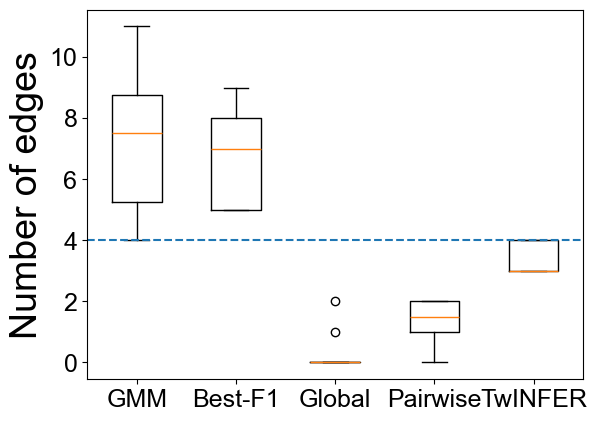

In [17]:
plt.boxplot(
    [
        metrics_grnboost_random['n_edges_gmm'],
        metrics_grnboost_random['n_edges_best'],
        metrics_grnboost_random['n_edges_global'],
        metrics_grnboost_random['n_edges_pairwise'],
        metrics_twinfer['TP']
    ],
    tick_labels=["GMM", "Best-F1", "Global", "Pairwise", "TwINFER"]
)
plt.axhline(4, linestyle = '--')
plt.ylabel("Number of edges")
plt.show()

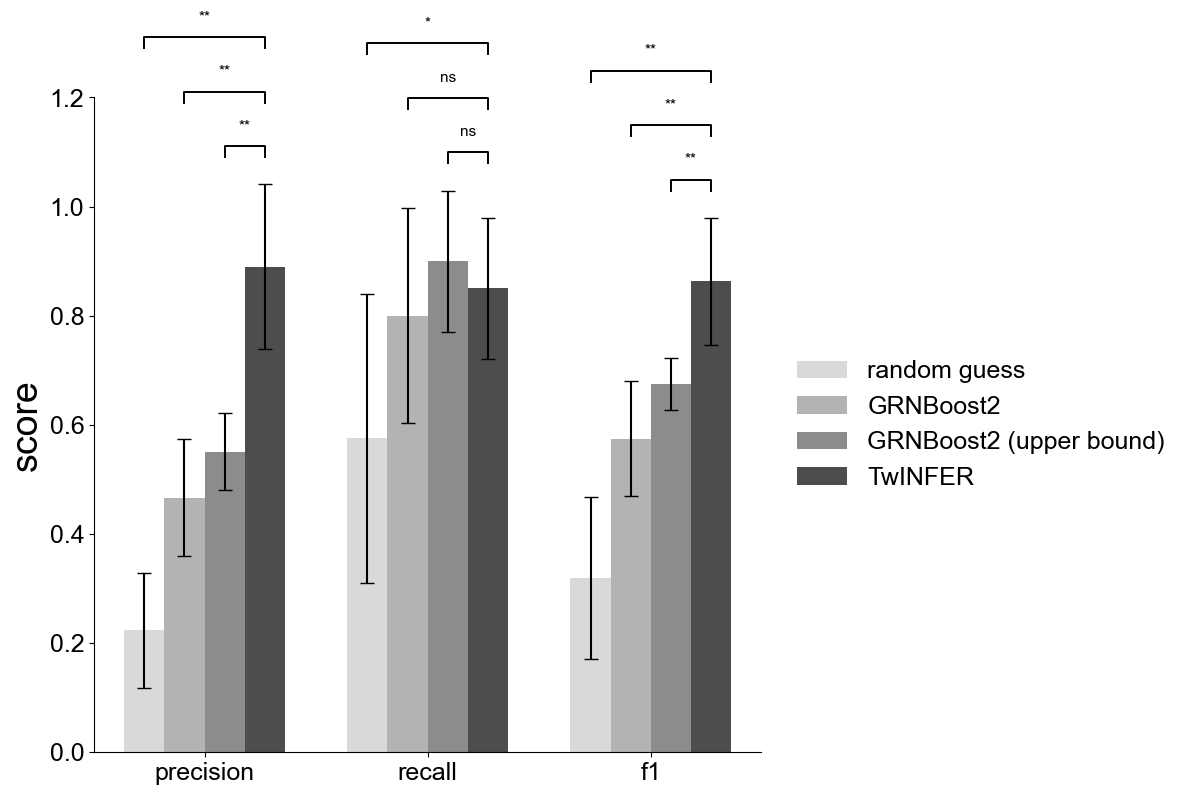

In [7]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.stats import wilcoxon
# from pathlib import Path

# # -------------------------------------------------
# # Metric order
# # -------------------------------------------------
# metrics_to_plot = ["precision", "recall", "f1"]
# width = 0.18
# x = np.arange(len(metrics_to_plot))

# # -------------------------------------------------
# # Compute means + std from existing combined_df
# # -------------------------------------------------
# metrics_rand = ["precision_random", "recall_random", "f1_random"]
# means_rand = combined_df[metrics_rand].mean().values
# stds_rand  = combined_df[metrics_rand].std().values

# metrics_gmm = ["precision_gmm_gmm", "recall_gmm_gmm", "f1_gmm_gmm"]
# means_gmm = combined_df[metrics_gmm].mean().values
# stds_gmm  = combined_df[metrics_gmm].std().values

# metrics_best = ["precision_gmm_best", "recall_gmm_best", "f1_gmm_best"]
# means_best = combined_df[metrics_best].mean().values
# stds_best  = combined_df[metrics_best].std().values

# metrics_twin = ["precision_twinfer", "recall_twinfer", "f1_twinfer"]
# means_twin = combined_df[metrics_twin].mean().values
# stds_twin  = combined_df[metrics_twin].std().values


# # -------------------------------------------------
# # Significance symbol function (Bonferroni)
# # -------------------------------------------------
# def get_symbol(p):
#     if p > 0.05:
#         return "ns"
#     elif p <= 0.0001:
#         return "****"
#     elif p <= 0.001:
#         return "***"
#     elif p <= 0.01:
#         return "**"
#     else:
#         return "*"


# def add_bracket(ax, x1, x2, y, h, label):

#     # draw bracket
#     ax.plot([x1, x1, x2, x2],
#             [y, y+h, y+h, y],
#             lw=1.4,
#             color="black",
#             clip_on=False)

#     # place text ABOVE bracket with fixed offset
#     ax.text(
#         (x1 + x2) / 2,
#         y + h + 0.05,   # constant offset
#         label,
#         ha="center",
#         va="top",
#         fontsize=11,
#         clip_on=False
#     )


# # -------------------------------------------------
# # Run paired Wilcoxon tests (collect raw p)
# # -------------------------------------------------
# raw_pvals = []
# test_info = []

# for i, metric in enumerate(metrics_to_plot):

#     twin_col = f"{metric}_twinfer"
#     gmm_col  = f"{metric}_gmm_gmm"
#     best_col = f"{metric}_gmm_best"
#     random_col = f"{metric}_random"

#     subset_gmm = combined_df[[twin_col, gmm_col]].dropna()
#     subset_best = combined_df[[twin_col, best_col]].dropna()
#     subset_random = combined_df[[twin_col, random_col]].dropna()

#     stat_random, p_random = wilcoxon(
#         subset_random[twin_col],
#         subset_random[random_col],
#         alternative="two-sided"
#     )

#     stat_gmm, p_gmm = wilcoxon(
#         subset_gmm[twin_col],
#         subset_gmm[gmm_col],
#         alternative="two-sided"
#     )


#     stat_best, p_best = wilcoxon(
#         subset_best[twin_col],
#         subset_best[best_col],
#         alternative="two-sided"
#     )

#     raw_pvals.extend([p_random, p_gmm, p_best])

#     test_info.append((i, "random", p_random))
#     test_info.append((i, "gmm", p_gmm))
#     test_info.append((i, "best", p_best))

# # Plot
# # -------------------------------------------------
# fig, ax = plt.subplots(figsize=(12, 8))

# bars_rand = ax.bar(x - 1.5*width, means_rand, width,
#                    yerr=stds_rand, capsize=5,
#                    label="random guess", color="0.85")

# bars_gmm = ax.bar(x - 0.5*width, means_gmm, width,
#                   yerr=stds_gmm, capsize=5,
#                   label="GRNBoost2", color="0.70")

# bars_best = ax.bar(x + 0.5*width, means_best, width,
#                    yerr=stds_best, capsize=5,
#                    label="GRNBoost2 (upper bound)", color="0.55")

# bars_twin = ax.bar(x + 1.5*width, means_twin, width,
#                    yerr=stds_twin, capsize=5,
#                    label="TwINFER", color="0.30")


# # Disable clipping
# for container in [bars_rand, bars_gmm, bars_best, bars_twin]:
#     for patch in container.patches:
#         patch.set_clip_on(False)

# for line in ax.lines:
#     line.set_clip_on(False)

# for spine in ax.spines.values():
#     spine.set_clip_on(False)

# ax.patch.set_clip_on(False)
# fig.patch.set_clip_on(False)


# # -------------------------------------------------
# # Add Bonferroni-corrected brackets
# # -------------------------------------------------
# counter = 0
# for i, metric in enumerate(metrics_to_plot):

#     y_base = max(
#         means_twin[i] + stds_twin[i],
#         means_best[i] + stds_best[i],
#         means_gmm[i] + stds_gmm[i]
#     )

#     # TwINFER vs Random
#     p_adj = p_bonf[counter]
#     label = get_symbol(p_adj)
#     add_bracket(ax,
#                 x[i] - 1.5*width,
#                 x[i] + 1.5*width,
#                 y_base + 0.25,
#                 0.02,
#                 label)
#     counter += 1

#     # TwINFER vs gmm
#     p_adj = raw_pvals[counter]
#     label = get_symbol(p_adj)
#     add_bracket(ax,
#                 x[i] - 0.5*width,
#                 x[i] + 1.5*width,
#                 y_base + 0.15,
#                 0.02,
#                 label)
#     counter += 1

#     # TwINFER vs Best
#     p_adj = p_bonf[counter]
#     label = get_symbol(p_adj)
#     add_bracket(ax,
#                 x[i] + 0.5*width,
#                 x[i] + 1.5*width,
#                 y_base + 0.05,
#                 0.02,
#                 label)
#     counter += 1


# # -------------------------------------------------
# # Cosmetics
# # -------------------------------------------------
# ax.set_xticks(x)
# ax.set_xticklabels(metrics_to_plot)
# ax.set_ylabel("score")
# ax.set_ylim(0, 1.20)

# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)

# leg = ax.legend(frameon=False,
#                 loc="center left",
#                 bbox_to_anchor=(1.02, 0.5))
# leg.set_clip_on(False)

# plt.tight_layout()

# # -------------------------------------------------
# # Save
# # -------------------------------------------------
# out = Path(path_to_plots)
# out.mkdir(parents=True, exist_ok=True)

# fig.savefig(out / "five_gene_comparison_stats.svg",
#             bbox_inches="tight", transparent=True)
# fig.savefig(out / "five_gene_comparison_stats.pdf",
#             bbox_inches="tight", transparent=True)
# fig.savefig(out / "five_gene_comparison_stats.png",
#             dpi=300, bbox_inches="tight", transparent=True)

# plt.show()

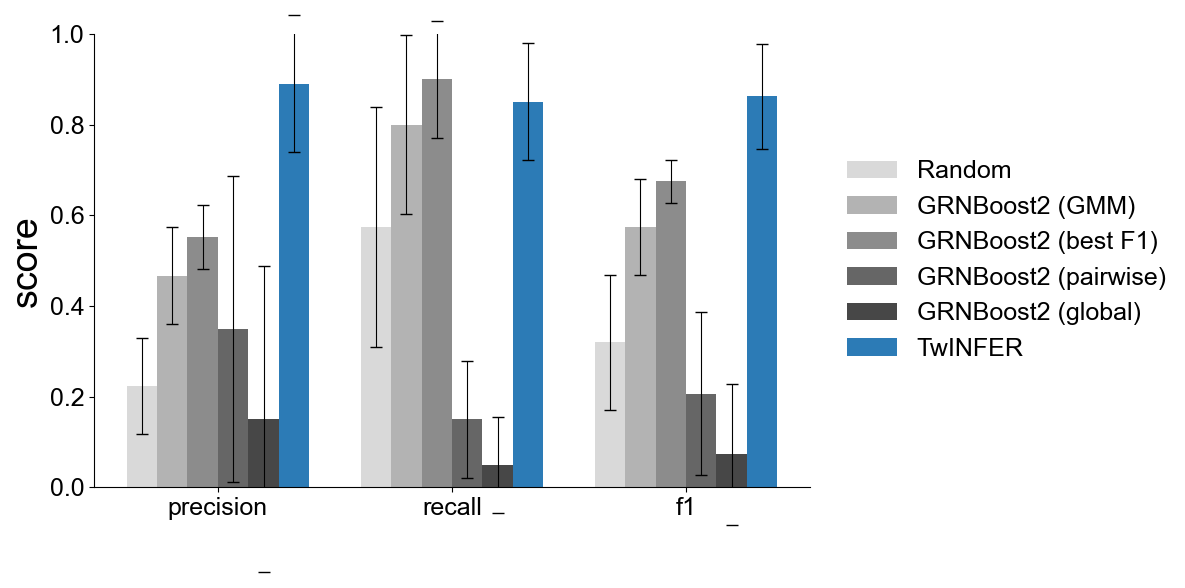

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
from pathlib import Path

metrics_to_plot = ["precision", "recall", "f1"]
n_methods = 6
x     = np.arange(len(metrics_to_plot))
width = 0.13
offsets = np.linspace(-(n_methods - 1) / 2, (n_methods - 1) / 2, n_methods) * width

# -------------------------------------------------
# Means + stds
# -------------------------------------------------
def get_mean_std(df, cols):
    return df[cols].mean().values, df[cols].std().values

means_rand,     stds_rand     = get_mean_std(combined_df, ["precision_random",   "recall_random",   "f1_random"])
means_gmm,      stds_gmm      = get_mean_std(combined_df, ["precision_gmm_gmm",  "recall_gmm_gmm",  "f1_gmm_gmm"])
means_best,     stds_best     = get_mean_std(combined_df, ["precision_gmm_best", "recall_gmm_best", "f1_gmm_best"])
means_pairwise, stds_pairwise = get_mean_std(combined_df, ["precision_pairwise", "recall_pairwise", "f1_pairwise"])
means_global,   stds_global   = get_mean_std(combined_df, ["precision_global",   "recall_global",   "f1_global"])
means_twin,     stds_twin     = get_mean_std(combined_df, ["precision_twinfer",  "recall_twinfer",  "f1_twinfer"])

# -------------------------------------------------
# Wilcoxon tests — TwINFER vs each method
# -------------------------------------------------
comparisons = [
    ("random",   "precision_random",   "recall_random",   "f1_random"),
    ("gmm",      "precision_gmm_gmm",  "recall_gmm_gmm",  "f1_gmm_gmm"),
    ("best",     "precision_gmm_best", "recall_gmm_best", "f1_gmm_best"),
    ("pairwise", "precision_pairwise", "recall_pairwise", "f1_pairwise"),
    ("global",   "precision_global",   "recall_global",   "f1_global"),
]

raw_pvals  = []
test_info  = []   # (metric_idx, method_name, raw_p)

for i, metric in enumerate(metrics_to_plot):
    twin_col = f"{metric}_twinfer"
    for method_name, p_col, r_col, f_col in comparisons:
        other_col = {"precision": p_col, "recall": r_col, "f1": f_col}[metric]
        subset = combined_df[[twin_col, other_col]].dropna()
        try:
            _, p = wilcoxon(subset[twin_col], subset[other_col], alternative="two-sided")
        except ValueError:
            p = 1.0
        raw_pvals.append(p)
        test_info.append((i, method_name, p))

# Bonferroni correction
p_bonf = raw_pvals

def get_symbol(p):
    if p > 0.05:   return "ns"
    elif p <= 0.0001: return "****"
    elif p <= 0.001:  return "***"
    elif p <= 0.01:   return "**"
    else:             return "*"

def add_bracket(ax, x1, x2, y, h, label):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y],
            lw=1.4, color="black", clip_on=False)
    ax.text((x1+x2)/2, y+h+0.02, label,
            ha="center", va="bottom", fontsize=9, clip_on=False)

# -------------------------------------------------
# Plot
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))

bar_specs = [
    (offsets[0], means_rand,     stds_rand,     "Random",                 "0.85"),
    (offsets[1], means_gmm,      stds_gmm,      "GRNBoost2 (GMM)",        "0.70"),
    (offsets[2], means_best,     stds_best,     "GRNBoost2 (best F1)",    "0.55"),
    (offsets[3], means_pairwise, stds_pairwise, "GRNBoost2 (pairwise)",   "0.40"),
    (offsets[4], means_global,   stds_global,   "GRNBoost2 (global)",     "0.28"),
    (offsets[5], means_twin,     stds_twin,     "TwINFER",                "#2c7bb6"),
]

all_bars = []
for offset, means, stds, label, color in bar_specs:
    bars = ax.bar(x + offset, means, width,
                  yerr=stds, capsize=4, label=label, color=color,
                  error_kw={"elinewidth": 0.8})
    all_bars.append(bars)

# Disable clipping
for container in all_bars:
    for patch in container.patches:
        patch.set_clip_on(False)
for line in ax.lines:
    line.set_clip_on(False)
for spine in ax.spines.values():
    spine.set_clip_on(False)
ax.patch.set_clip_on(False)
fig.patch.set_clip_on(False)

# -------------------------------------------------
# Brackets — TwINFER vs each method per metric
# -------------------------------------------------
# bracket heights above the tallest bar+err for each metric
bracket_gap  = 0.06
bracket_h    = 0.02
all_means    = [means_rand, means_gmm, means_best, means_pairwise, means_global, means_twin]
all_stds     = [stds_rand,  stds_gmm,  stds_best,  stds_pairwise,  stds_global,  stds_twin]

method_offsets = {
    "random":   offsets[0],
    "gmm":      offsets[1],
    "best":     offsets[2],
    "pairwise": offsets[3],
    "global":   offsets[4],
}

# bonf_idx = 0
# for i, metric in enumerate(metrics_to_plot):
#     y_base = max(m[i] + s[i] for m, s in zip(all_means, all_stds)) + 0.03

#     for level, (method_name, _, _, _) in enumerate(comparisons):
#         p_adj = p_bonf[bonf_idx]
#         label = get_symbol(p_adj)
#         y_bracket = y_base + level * bracket_gap
#         add_bracket(ax,
#                     x[i] + method_offsets[method_name],
#                     x[i] + offsets[5],   # TwINFER
#                     y_bracket,
#                     bracket_h,
#                     label)
#         bonf_idx += 1

# -------------------------------------------------
# Cosmetics
# -------------------------------------------------
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylabel("score")
ax.set_ylim(0, 1.6)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.ylim(0,1)
leg = ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5))
leg.set_clip_on(False)

plt.tight_layout()

# -------------------------------------------------
# Save
# -------------------------------------------------
out = Path(path_to_plots)
# out.mkdir(parents=True, exist_ok=True)
# fig.savefig(out / "five_gene_comparison_stats.svg", bbox_inches="tight", transparent=True)
# fig.savefig(out / "five_gene_comparison_stats.pdf", bbox_inches="tight", transparent=True)
# fig.savefig(out / "five_gene_comparison_stats.png", dpi=300, bbox_inches="tight", transparent=True)
plt.show()